In [1]:
# ============================================================
# 01 - Exploratory Data Analysis (EDA)
# ============================================================
# Owner: Benjamin Muniz
# Purpose: Load all four raw datasets and explore their
#          structure before any cleaning or modification.
#          Document findings with markdown cells below each
#          section. DO NOT modify the data in this notebook.
# ============================================================

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================
# Load all three datasets
# ================================================

df_email1 = pd.read_csv('../data/raw/phishing_email_kaggle1.csv')
df_email2 = pd.read_csv('../data/raw/phishing_email_kaggle2.csv')
df_url    = pd.read_csv('../data/raw/phishing_url.csv')

datasets = {
    'phishing email kaggle1': df_email1,
    'phising email kaggle 2': df_email2,
    'phishing url dataset': df_url
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"{'='*50}")
    print("Shape:        ", df.shape)
    print("Columns:      ", df.columns.tolist())
    print("Null values:\n", df.isnull().sum())
    print("Label column: ", df.iloc[:, -1].value_counts())


Dataset: phishing email kaggle1
Shape:         (82486, 2)
Columns:       ['text_combined', 'label']
Null values:
 text_combined    0
label            0
dtype: int64
Label column:  label
1    42891
0    39595
Name: count, dtype: int64

Dataset: phising email kaggle 2
Shape:         (18650, 3)
Columns:       ['Unnamed: 0', 'Email Text', 'Email Type']
Null values:
 Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64
Label column:  Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Dataset: phishing url dataset
Shape:         (235795, 56)
Columns:       ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOt

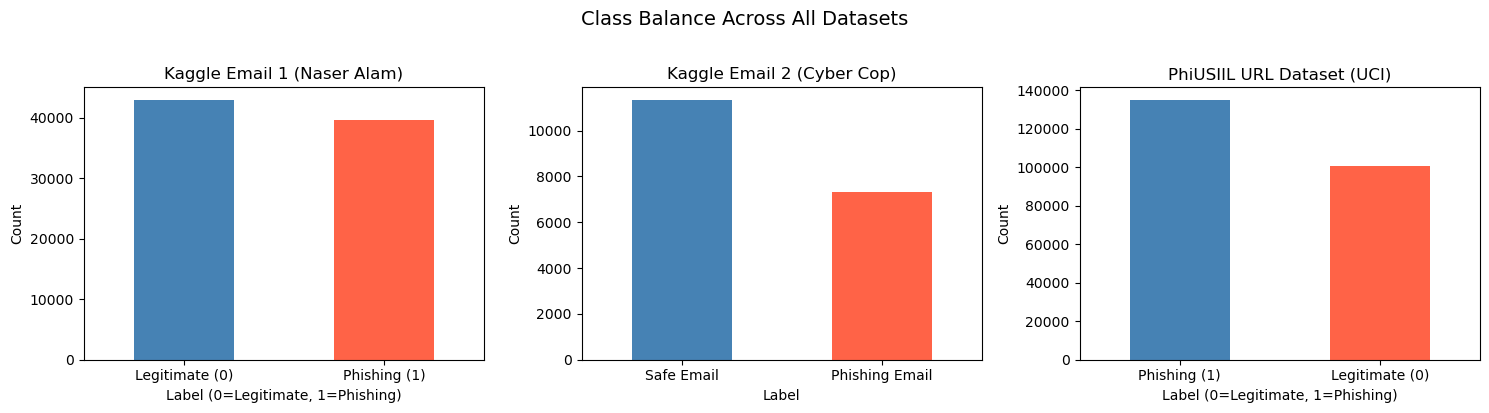

In [3]:
# ================================================
# Class Balance Visualization
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Email1
df_email1['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Kaggle Email 1 (Naser Alam)')
axes[0].set_xlabel('Label (0=Legitimate, 1=Phishing)')
axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Email2
df_email2['Email Type'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Kaggle Email 2 (Cyber Cop)')
axes[1].set_xlabel('Label')
axes[1].set_xticklabels(['Safe Email', 'Phishing Email'], rotation=0)
axes[1].set_ylabel('Count')

# URL
df_url['label'].value_counts().plot(
    kind='bar', ax=axes[2], color=['steelblue', 'tomato']
)
axes[2].set_title('PhiUSIIL URL Dataset (UCI)')
axes[2].set_xlabel('Label (0=Legitimate, 1=Phishing)')
axes[2].set_xticklabels(['Phishing (1)', 'Legitimate (0)'], rotation=0)
axes[2].set_ylabel('Count')

plt.suptitle('Class Balance Across All Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/class_balance.png', dpi=150)
plt.show()

## EDA Summary

### Kaggle Email 1 (Naser Alam) — phishing_email_kaggle1.csv
- Shape: 82,486 rows, 2 columns (text_combined, label)
- Labels: already standardized as 0/1
- Null values: none
- Class balance: 42,891 phishing (52%) / 39,595 legitimate (48%) — balanced, no SMOTE needed
- Notes: text is preprocessed plain text, no raw HTML or URLs present
         better suited for content-based features (Theryn)

### Kaggle Email 2 (Cyber Cop) — phishing_email_kaggle2.csv
- Shape: 18,650 rows, 3 columns (Unnamed: 0, Email Text, Email Type)
- Labels: string format — 'Safe Email' / 'Phishing Email', needs mapping
- Null values: 16 nulls in Email Text column, needs dropping
- Class balance: 11,322 safe (61%) / 7,328 phishing (39%) — borderline, monitor
- Notes: has an unnamed index column that needs to be dropped
         text is raw email content, better suited for content-based features (Theryn)

### PhiUSIIL URL Dataset (UCI) — phishing_url.csv
- Shape: 235,795 rows, 56 columns
- Labels: already standardized as 0/1
- Null values: none
- Class balance: 134,850 legitimate (57%) / 100,945 phishing (43%) — acceptable
- Notes: features already extracted, includes URL structure, domain info,
         HTML page features, and security indicators — primary dataset for URL features
         FILENAME, URL, Domain, TLD, Title columns are non-numeric and need
         to be dropped or encoded before training

In [4]:
# ================================================
# Identify non-numeric columns in URL dataset
# (these need to be dropped before training)
# ================================================

non_numeric = df_url.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric columns in URL dataset:")
print(non_numeric)
print(f"\nTotal non-numeric: {len(non_numeric)}")
print(f"Total columns: {df_url.shape[1]}")
print(f"Usable numeric columns: {df_url.shape[1] - len(non_numeric)}")

Non-numeric columns in URL dataset:
['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

Total non-numeric: 5
Total columns: 56
Usable numeric columns: 51
